In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df =pd.read_csv(r"D:\data\DATA\BIA\theory\data\AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [21]:
round(df['isFraud'].value_counts()[1] /df['isFraud'].value_counts()[0] *100,2)


np.float64(0.13)

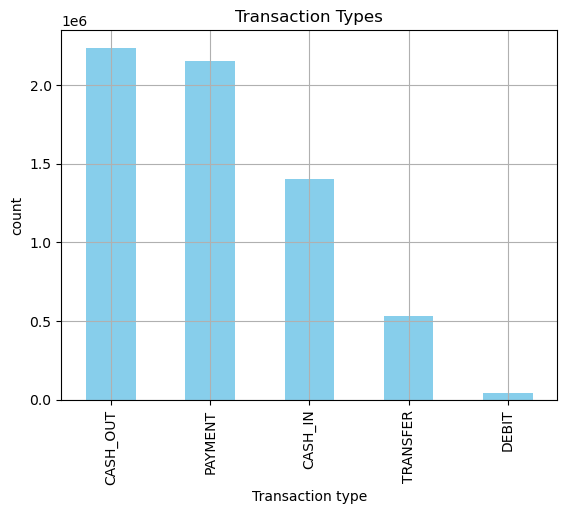

In [37]:
df["type"].value_counts().plot(kind='bar',title ="Transaction Types" , color ='skyblue')
plt.xlabel("Transaction type")
plt.ylabel("count")
plt.grid()
plt.show()

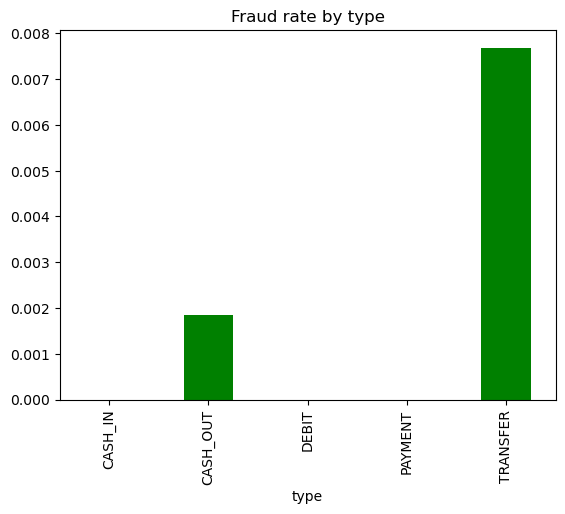

In [49]:
fraud_by_type = df.groupby("type")["isFraud"].mean()
fraud_by_type.plot(kind='bar',title ='Fraud rate by type',color = 'green')
plt.show()

In [51]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

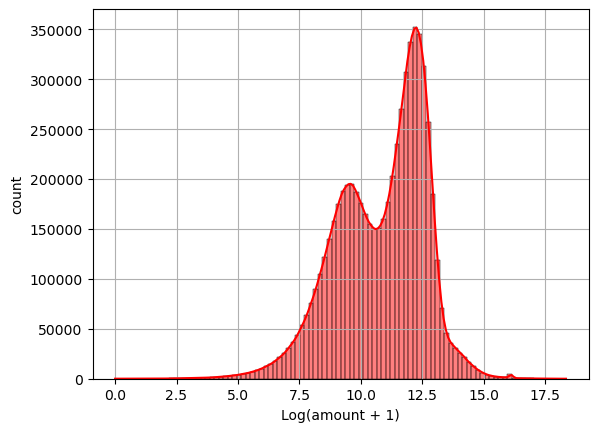

In [60]:
 sns.histplot(np.log1p(df['amount']),bins = 100 , color='red',kde=True)
plt.xlabel('Log(amount + 1)')
plt.ylabel('count')
plt.grid()
plt.show()

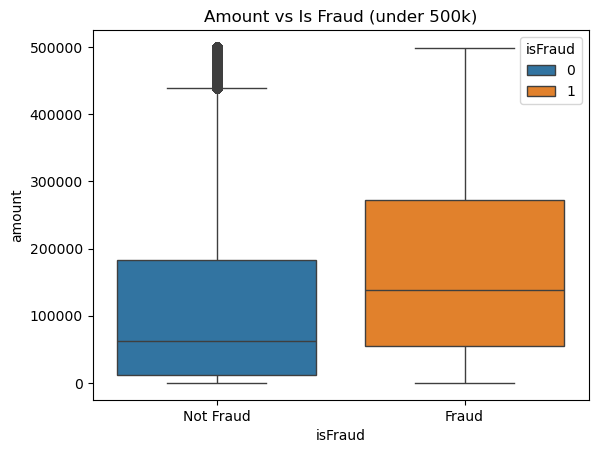

In [75]:
sns.boxplot(data=df[df['amount'] < 500000], x='isFraud', y='amount',hue='isFraud')
plt.title("Amount vs Is Fraud (under 500k)")
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()


In [78]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [92]:
df['balance_diffrence_Orignal']= df['oldbalanceOrg']-df['newbalanceOrig']
df['balance_diffrence_destination']= df['newbalanceDest'] - df['oldbalanceDest']

In [93]:
(df['balance_diffrence_Orignal'] <0).sum()


np.int64(1399253)

In [95]:
top_sender =df['nameOrig'].value_counts().head(10)
top_sender

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [98]:
top_receiver = df['nameDest'].value_counts().head(10)
top_receiver

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [103]:
fraud_user = df[df['isFraud'] ==1]['nameOrig'].value_counts().head(10)
fraud_user

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C1039979813    1
C2089752665    1
C1614818636    1
C40604503      1
C1970706589    1
Name: count, dtype: int64

In [111]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

In [133]:
df.drop(columns='step',inplace=True)

<Axes: xlabel='type', ylabel='count'>

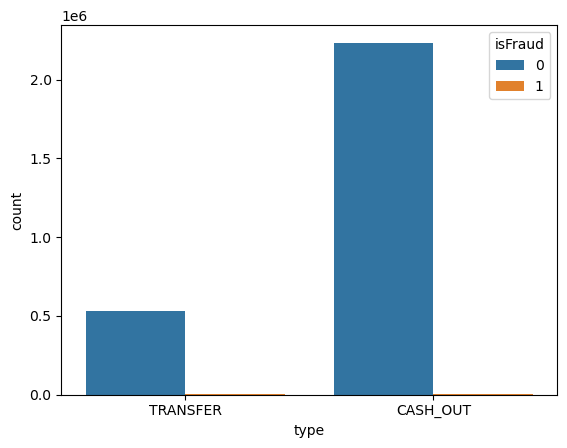

In [115]:
sns.countplot(data=fraud_types, x='type', hue='isFraud')

In [119]:
corr = df[['oldbalanceOrg', 'newbalanceOrig','oldbalanceDest', 'newbalanceDest', 'isFraud',]].corr()
corr

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
oldbalanceOrg,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.010154,-0.008148,-0.005885,0.000535,1.000000


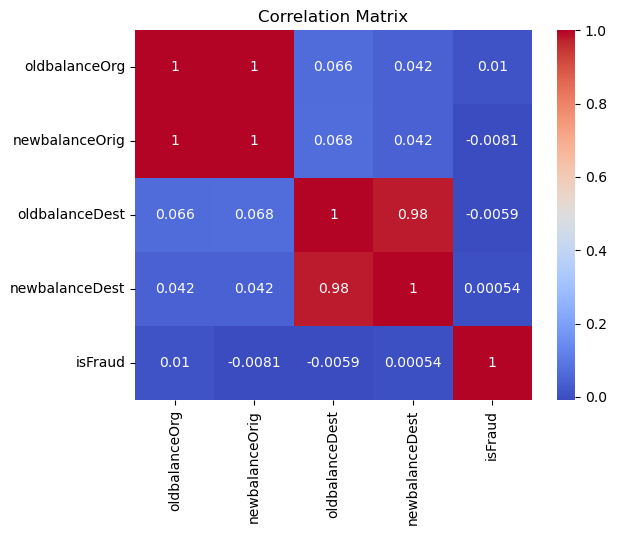

In [122]:
sns.heatmap(corr,annot=True ,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report ,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [137]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diffrence_Orignal,balance_diffrence_destination
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [135]:
df_model = df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)

In [138]:
num_cols = df_model.select_dtypes(include=['number']).columns
print(num_cols)

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'balance_diffrence_Orignal',
       'balance_diffrence_destination'],
      dtype='object')


In [139]:
cat =['type']
numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest']

In [141]:
X= df_model.drop('isFraud',axis=1)
y=df_model['isFraud']

In [142]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state =42,test_size=0.3,stratify = y)

In [144]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),numerical),
        ('cater',OneHotEncoder(),cat)
    ],
    remainder ='drop'

    
)

In [146]:
pipeline = Pipeline([
    ('prep',preprocessor),
    ('clf',LogisticRegression(class_weight ='balanced',max_iter=1000))])



In [147]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cater', OneHotEncoder(),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [149]:
y_pred = pipeline.predict(X_test)

In [153]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [154]:
confusion_matrix(y_test,y_pred)

array([[1804747,  101575],
       [    151,    2313]])

In [157]:
pipeline.score(X_test,y_test)*100

94.67064406381857

In [159]:
import joblib 
joblib.dump(pipeline,"fraud_detection.pkl")

['fraud_detection.pkl']